In [77]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pathlib import Path
import warnings
data_dir = Path("cleaned_data")
spark = SparkSession.builder \
.appName("Read Parquet") \
    .config("spark.driver.memory", "12g")\
        .getOrCreate()

yellow_taxi = spark.read.parquet(f"{data_dir / 'yellow_data.parquet'}")
fhvhv_taxi = spark.read.parquet(f"{data_dir / 'fhvhv_data.parquet'}")
warnings.filterwarnings("ignore", module="pyspark")
yellow_taxi.show(1)

+-------------------+------------+------------+-------+
|               date|PULocationID|total_amount|Borough|
+-------------------+------------+------------+-------+
|2023-05-01 00:42:49|         138|       57.15| Queens|
+-------------------+------------+------------+-------+
only showing top 1 row


In [78]:
daily_taxi_earnings = (
    yellow_taxi
    .withColumn("day", F.to_date("date"))
    .groupBy("day", "PULocationID")
    .agg(F.sum("total_amount").alias("total_amount"))
    .orderBy("day", "PULocationID")
)
print(daily_taxi_earnings.count())

262332


In [79]:
import geopandas as gpd
geo_data = gpd.read_file("data/taxi_zones/taxi_zones.shp")
geo_data.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


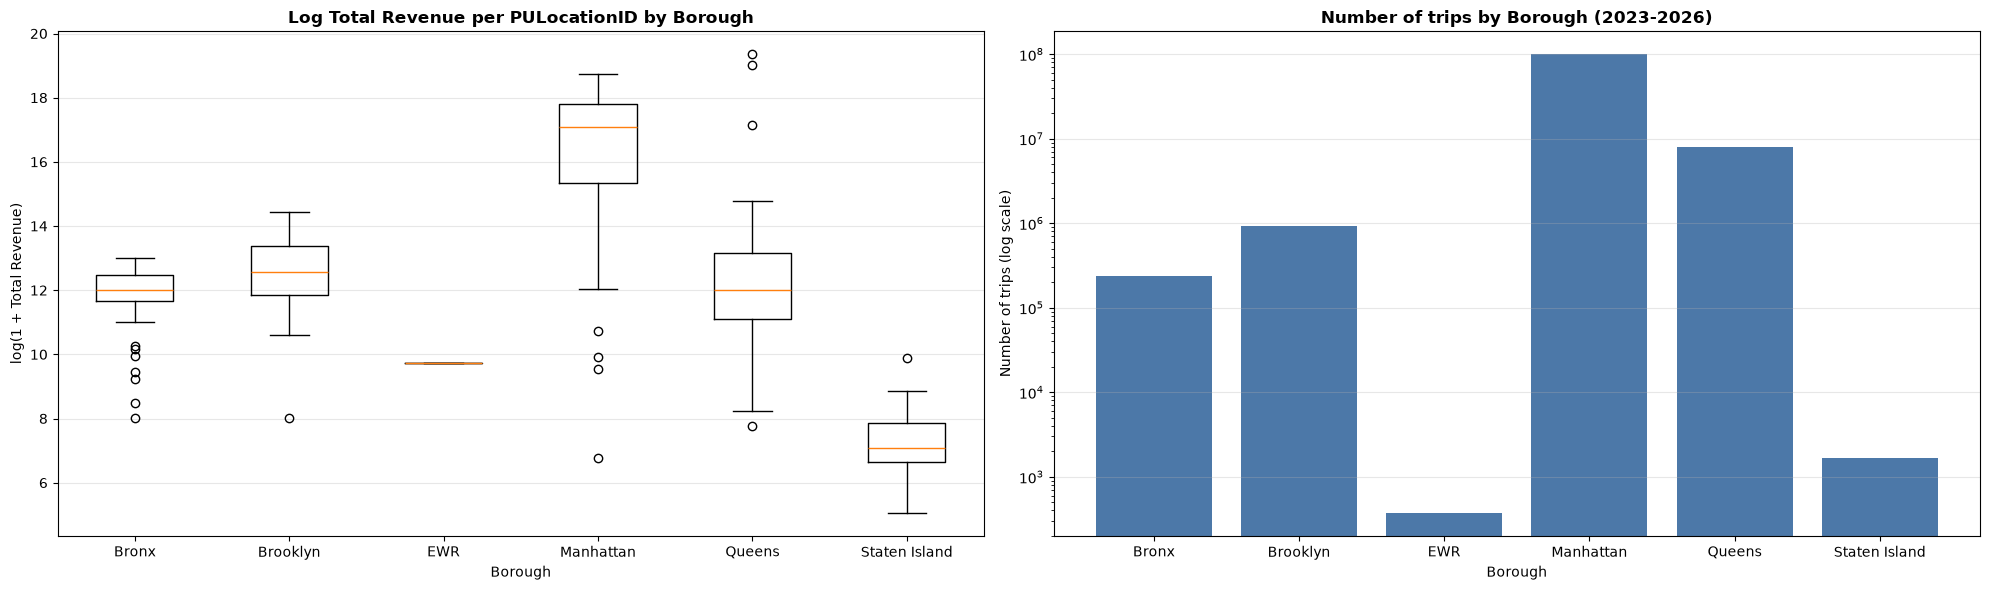

In [80]:
import matplotlib.pyplot as plt
# --------------------------------------------------
# Step 3: Total revenue for each PULocationID
# over the ENTIRE time period
# --------------------------------------------------

location_total_revenue = (
    yellow_taxi
    .groupBy("PULocationID", "Borough")
    .agg(
        F.sum("total_amount").alias("total_revenue")
    )
    .withColumn(
        "log_total_revenue",
        F.log1p("total_revenue")
    )
)


# --------------------------------------------------
# Step 4: Count number of trips for each Borough
# --------------------------------------------------

borough_trip_counts = (
    yellow_taxi
    .groupBy("Borough")
    .agg(
        F.count("*").alias("number_of_trips")
    )
    .orderBy("Borough")
)


# --------------------------------------------------
# Step 5: Convert both results to Pandas
# --------------------------------------------------

location_total_revenue_pd = location_total_revenue.toPandas()
borough_trip_counts_pd = borough_trip_counts.toPandas()


# --------------------------------------------------
# Step 6: Prepare boxplot data
# --------------------------------------------------

boroughs = sorted(
    location_total_revenue_pd["Borough"]
    .dropna()
    .unique()
)

boxplot_data = [
    location_total_revenue_pd.loc[
        location_total_revenue_pd["Borough"] == borough,
        "log_total_revenue"
    ].dropna()
    for borough in boroughs
]


# --------------------------------------------------
# Step 7: Create 1x2 subplot
# --------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(20, 6)
)


# ==================================================
# LEFT: Boxplot of log total revenue
# ==================================================

axes[0].boxplot(
    boxplot_data,
    tick_labels=boroughs
)

axes[0].set_title(
    "Log Total Revenue per PULocationID by Borough",
    fontweight="bold"
)

axes[0].set_xlabel("Borough")
axes[0].set_ylabel("log(1 + Total Revenue)")
axes[0].grid(axis="y", alpha=0.3)


# ==================================================
# RIGHT: Number of trips by Borough
# ==================================================

axes[1].bar(
    borough_trip_counts_pd["Borough"],
    borough_trip_counts_pd["number_of_trips"],
    color='#4C78A8'
)

axes[1].set_title(
    "Number of trips by Borough (2023-2026)",
    fontweight="bold"
)

axes[1].set_xlabel("Borough")
axes[1].set_ylabel("Number of trips (log scale)")
axes[1].set_yscale("log")
axes[1].grid(axis="y", alpha=0.3)


# --------------------------------------------------
# Final formatting
# --------------------------------------------------

plt.tight_layout()
plt.show()

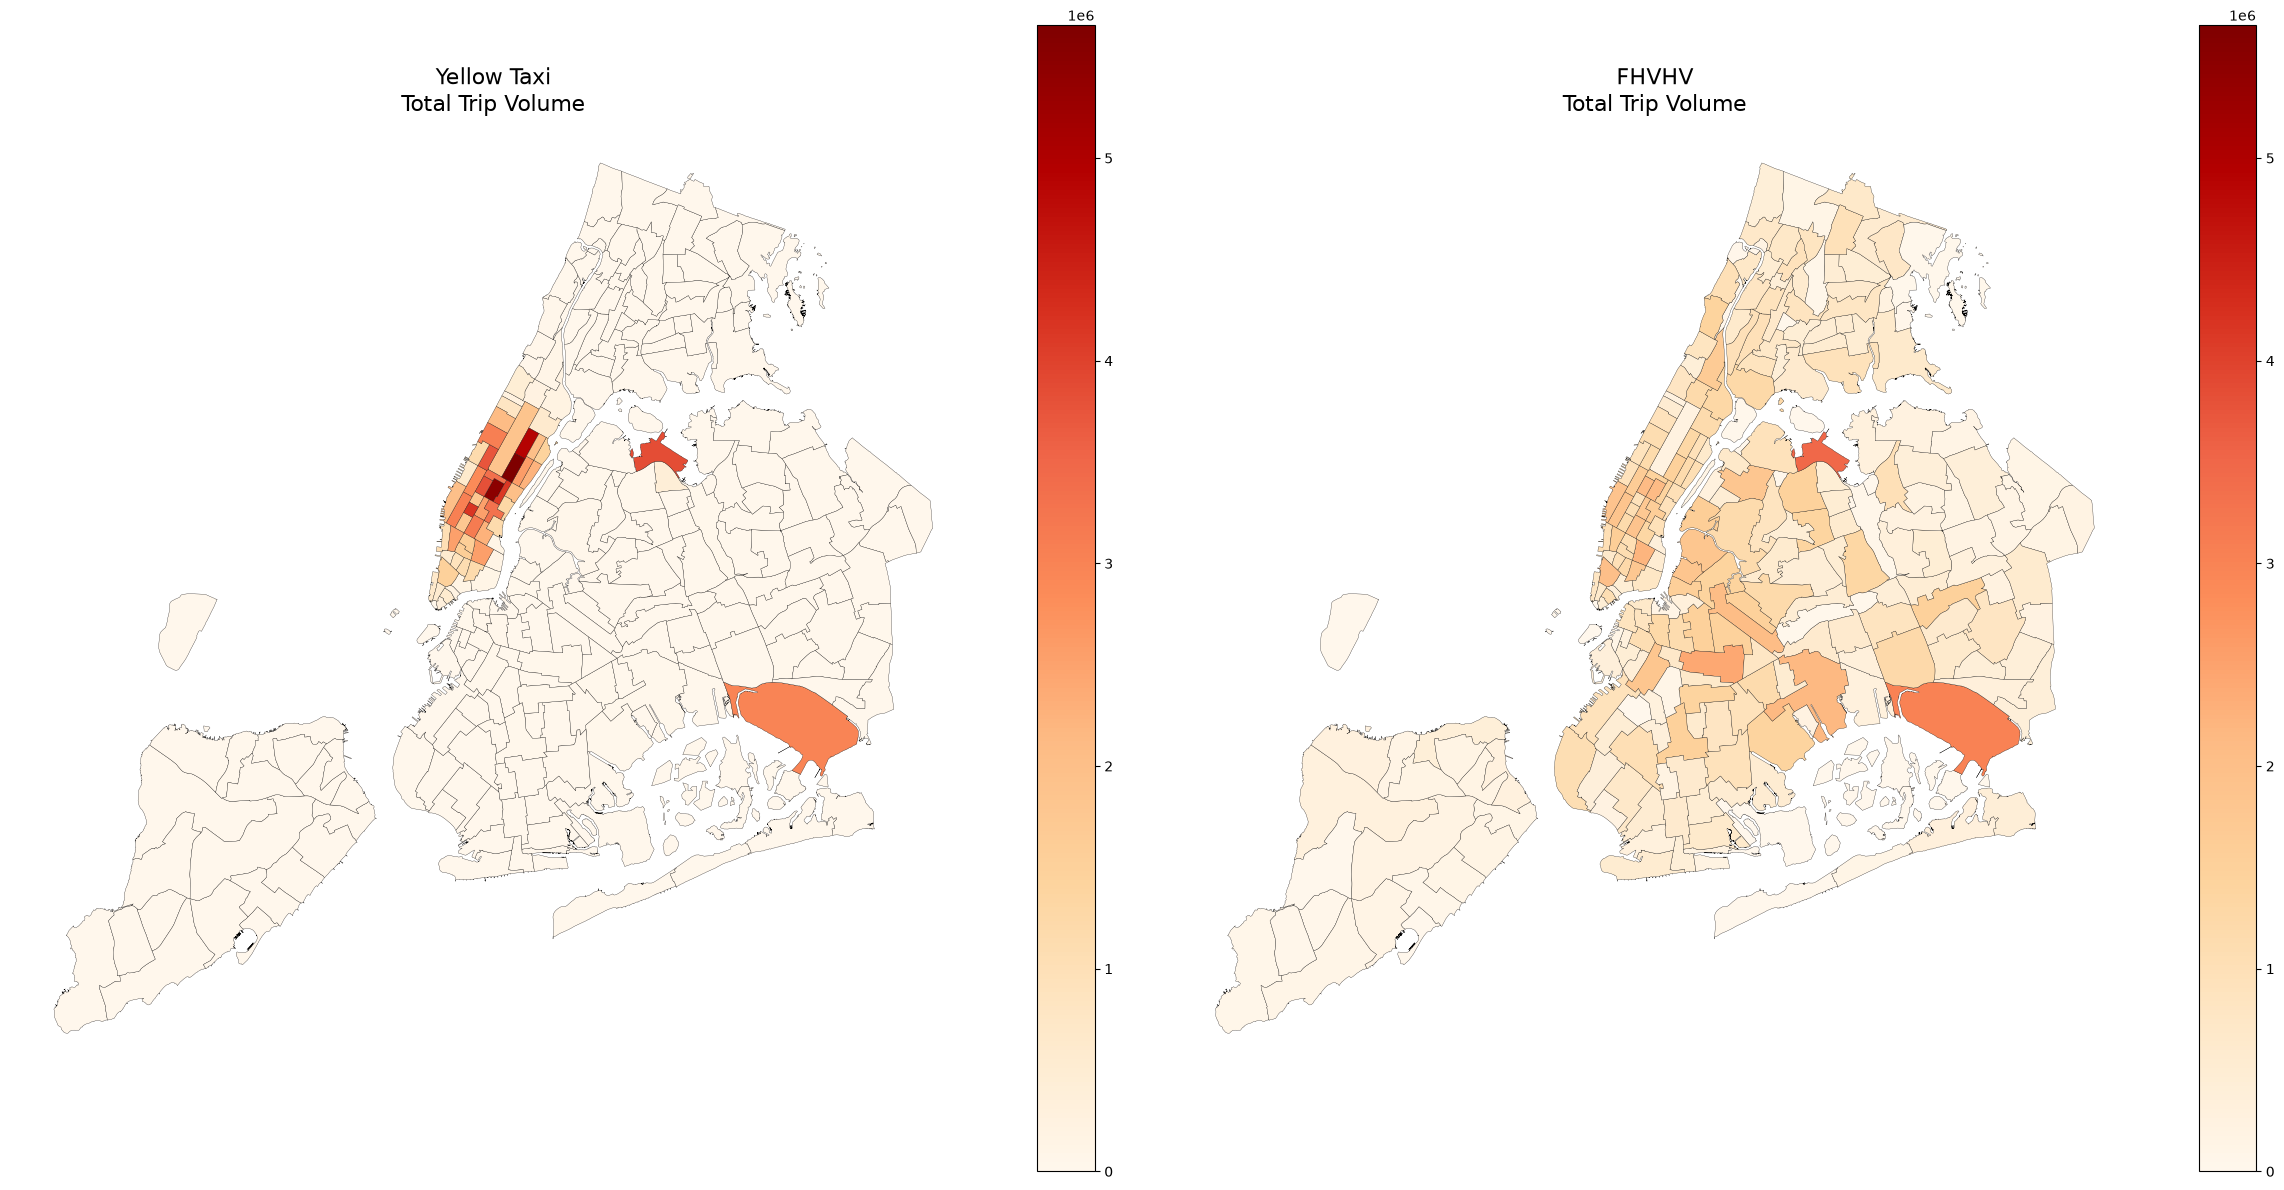

In [81]:
# ---------------------------------------------------------
# 1. Yellow Taxi: count trips across ALL dates
# ---------------------------------------------------------
yellow_total = (
    yellow_taxi
    .groupBy("PULocationID")
    .count()
    .withColumnRenamed("count", "trip_volume")
)

yellow_pd = yellow_total.toPandas()


# ---------------------------------------------------------
# 2. FHVHV: sum trip volume across ALL dates
# ---------------------------------------------------------
fhvhv_total = (
    fhvhv_taxi
    .groupBy("PULocationID")
    .sum("trip_volume")
    .withColumnRenamed("sum(trip_volume)", "trip_volume")
)

fhvhv_pd = fhvhv_total.toPandas()


# ---------------------------------------------------------
# 3. Load NYC Taxi Zone shapefile
# ---------------------------------------------------------
taxi_zones = gpd.read_file("data/taxi_zones/taxi_zones.shp")

taxi_zones["LocationID"] = taxi_zones["LocationID"].astype(int)

yellow_pd["PULocationID"] = yellow_pd["PULocationID"].astype(int)
fhvhv_pd["PULocationID"] = fhvhv_pd["PULocationID"].astype(int)


# ---------------------------------------------------------
# 4. Join trip volumes to the geographic zones
# ---------------------------------------------------------
yellow_map = taxi_zones.merge(
    yellow_pd,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

fhvhv_map = taxi_zones.merge(
    fhvhv_pd,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

# Zones with no trips get 0
yellow_map["trip_volume"] = yellow_map["trip_volume"].fillna(0)
fhvhv_map["trip_volume"] = fhvhv_map["trip_volume"].fillna(0)


# ---------------------------------------------------------
# 5. SAME color scale for both maps
# ---------------------------------------------------------
vmin = min(
    yellow_map["trip_volume"].min(),
    fhvhv_map["trip_volume"].min()
)

vmax = max(
    yellow_map["trip_volume"].max(),
    fhvhv_map["trip_volume"].max()
)


# ---------------------------------------------------------
# 6. Create side-by-side choropleth maps
# ---------------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(24, 12)
)

# Yellow Taxi
yellow_map.plot(
    column="trip_volume",
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    vmin=vmin,
    vmax=vmax,
    ax=axes[0],
    missing_kwds={"color": "lightgrey"}
)

axes[0].set_title(
    "Yellow Taxi\nTotal Trip Volume",
    fontsize=16
)
axes[0].axis("off")


# FHVHV
fhvhv_map.plot(
    column="trip_volume",
    cmap="OrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    vmin=vmin,
    vmax=vmax,
    ax=axes[1],
    missing_kwds={"color": "lightgrey"}
)

axes[1].set_title(
    "FHVHV\nTotal Trip Volume",
    fontsize=16
)
axes[1].axis("off")


plt.tight_layout()
plt.show()

In [82]:
from utils import add_stations
yellow_data_with_stations = add_stations(yellow_total, spark)

In [83]:
daily_taxi_earnings = add_stations(daily_taxi_earnings, spark)
daily_taxi_earnings.show(5)

+----------+------------+------------------+------------+
|       day|PULocationID|      total_amount|num_stations|
+----------+------------+------------------+------------+
|2023-05-01|          95|            381.71|           3|
|2023-05-05|         253|             66.24|           0|
|2023-05-06|         229|43226.779999999875|           1|
|2023-05-09|         235|             203.7|           2|
|2023-05-12|         219|414.20000000000005|           0|
+----------+------------+------------------+------------+
only showing top 5 rows


In [84]:
# Create a Python dictionary from GeoPandas
borough_mapping = dict(
    zip(geo_data["LocationID"], geo_data["borough"])
)

# Create a Spark map expression
mapping_expr = F.create_map(
    *[
        item
        for location_id, borough in borough_mapping.items()
        for item in (F.lit(int(location_id)), F.lit(borough))
    ]
)

# Add Borough column
daily_taxi_earnings_with_station = daily_taxi_earnings.withColumn(
    "Borough",
    mapping_expr[F.col("PULocationID")]
)

In [85]:
daily_taxi_earnings_with_station.show(2)

+----------+------------+------------+------------+-------+
|       day|PULocationID|total_amount|num_stations|Borough|
+----------+------------+------------+------------+-------+
|2023-05-01|          95|      381.71|           3| Queens|
|2023-05-05|         253|       66.24|           0| Queens|
+----------+------------+------------+------------+-------+
only showing top 2 rows


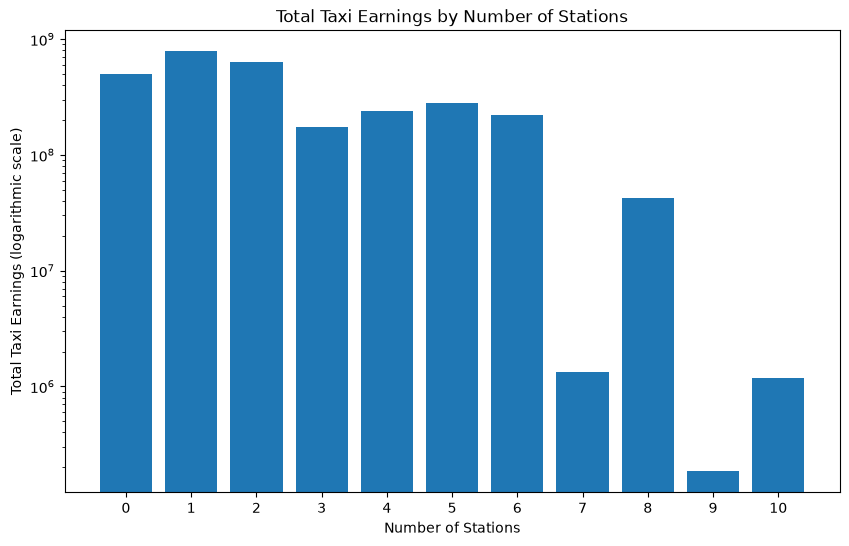

In [86]:
# Aggregate total trip volume by number of stations
plot_df = (
    daily_taxi_earnings_with_station.groupBy("num_stations")
      .agg(F.sum("total_amount").alias("total_amount"))
      .orderBy("num_stations")
)

# Convert to Pandas
pdf = plot_df.toPandas()

# Bar plot
plt.figure(figsize=(10, 6))
plt.bar(
    pdf["num_stations"].astype(str),
    pdf["total_amount"]
)

plt.xlabel("Number of Stations")
plt.ylabel("Total Taxi Earnings (logarithmic scale)")
plt.title("Total Taxi Earnings by Number of Stations")
plt.yscale("log")  # Log scale for better visualization
plt.show()

In [87]:
# Create a Python dictionary from GeoPandas
borough_mapping = dict(
    zip(geo_data["LocationID"], geo_data["borough"])
)

# Create a Spark map expression
mapping_expr = F.create_map(
    *[
        item
        for location_id, borough in borough_mapping.items()
        for item in (F.lit(int(location_id)), F.lit(borough))
    ]
)

# Add Borough column
yellow_data_with_stations = yellow_data_with_stations.withColumn(
    "Borough",
    mapping_expr[F.col("PULocationID")]
)

## Testing for association between `num_stations` and `log1p(total_amount)`


In [88]:
import statsmodels.formula.api as smf
df = (
    daily_taxi_earnings_with_station
    .filter(F.col("Borough").isNotNull())
    .withColumn(
        "log_total_amount",
        F.log1p("total_amount")
    )
)
pdf = df.select(
    "Borough",
    "num_stations",
    "log_total_amount"
).toPandas()

model = smf.ols(
    "log_total_amount ~ C(num_stations) + C(Borough)",
    data=pdf
).fit()
categorical_model = smf.ols(
    "log_total_amount ~ C(Borough) + C(num_stations)",
    data=pdf
).fit(cov_type="HC3")

for param in categorical_model.params.index:
    print(
        f"{param:45s} "
        f"coef = {categorical_model.params[param]: .6f}    "
        f"p = {categorical_model.pvalues[param]:.6g}"
    )

Intercept                                     coef =  4.391297    p = 0
C(Borough)[T.Brooklyn]                        coef =  0.403650    p = 0
C(Borough)[T.EWR]                             coef = -0.573577    p = 4.23457e-36
C(Borough)[T.Manhattan]                       coef =  4.374609    p = 0
C(Borough)[T.Queens]                          coef =  0.894664    p = 0
C(Borough)[T.Staten Island]                   coef = -1.389173    p = 0
C(num_stations)[T.1]                          coef =  0.767892    p = 0
C(num_stations)[T.2]                          coef =  0.610128    p = 0
C(num_stations)[T.3]                          coef =  0.339371    p = 4.29555e-229
C(num_stations)[T.4]                          coef =  0.649883    p = 0
C(num_stations)[T.5]                          coef =  0.884099    p = 0
C(num_stations)[T.6]                          coef =  1.116855    p = 0
C(num_stations)[T.7]                          coef =  0.880133    p = 0
C(num_stations)[T.8]                       

## Testing for interaction between Borough and `num_stations`.
In this section, we aim to see whether the effect of `num_stations` on `log1p(total_amount)` changes between boroughs. 

The results show that there is insufficient evidence at the 5% level of significance that the effect of `num_stations` on `log1p(total_amount)` changes across boroughs. 

The notable exception is with Newark International Airport but that is an unreliable result since EWR has much fewer instances available than the other boroughs. 

In [89]:
interaction_model = smf.ols(
    "log_total_amount ~ num_stations * C(Borough)",
    data=pdf
).fit(cov_type="HC3")

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:       log_total_amount   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                 3.947e+04
Date:                Sat, 29 Aug 2026   Prob (F-statistic):               0.00
Time:                        01:05:58   Log-Likelihood:            -4.8460e+05
No. Observations:              262332   AIC:                         9.692e+05
Df Residuals:                  262321   BIC:                         9.693e+05
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 11, but rank is 10
  warnings.warn('covariance of constraints does not have full '


## Final statistical test: Whether having a station at all is more revealing than the number of stations.
In this section, we tested whether a zone having at least one train station as opposed to none affects taxi revenue more than the number of stations that exist. 

The underlying logic is that a zone having any train station at all is likely to be a zone that is quite large and dense in population, which naturally lends to more customers demanding rides and therefore higher earnings in total per day. 

Zones with no stations are likely to be relatively small or not contain many residents in the surrounding areas that would demand yellow taxis.

In [90]:
pdf["has_station"] = (pdf["num_stations"] > 0).astype(int)
binary_model = smf.ols(
    "log_total_amount ~ C(Borough) + has_station",
    data=pdf
).fit(cov_type="HC3")

print(binary_model.summary())

                            OLS Regression Results                            
Dep. Variable:       log_total_amount   R-squared:                       0.609
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                 6.377e+04
Date:                Sat, 29 Aug 2026   Prob (F-statistic):               0.00
Time:                        01:06:51   Log-Likelihood:            -4.8351e+05
No. Observations:              262332   AIC:                         9.670e+05
Df Residuals:                  262325   BIC:                         9.671e+05
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [38]:
# save the combined dataset to a parquet file
combined.write.mode("overwrite").parquet("training_data/combined_yellow_fhvhv.parquet")

NameError: name 'combined' is not defined

In [ ]:
flight_data = spark.read.csv('data/airport_traffic_data.csv', header=True, inferSchema=True)
flight_data.printSchema()

root
 |-- Activity Period: timestamp (nullable = true)
 |-- Airport Code: string (nullable = true)
 |-- Terminal Port: string (nullable = true)
 |-- Marketing Airline Name: string (nullable = true)
 |-- Direction: string (nullable = true)
 |-- Market: string (nullable = true)
 |-- World Region: string (nullable = true)
 |-- Revenue Passenger Volume: integer (nullable = true)
 |-- Non-Revenue Passenger Volume: integer (nullable = true)
 |-- Freight Volume: double (nullable = true)
 |-- Mail Volume: double (nullable = true)
 |-- Total Flights: integer (nullable = true)



In [ ]:
# filter down to passenger flights
# within the desired time interval, and only inbound flights
passenger_flights = (
    flight_data
    .filter(
        (F.col('Revenue Passenger Volume') > 0) &
        (F.col('direction') == 'Inbound') & 
        (F.col('Activity Period') >= '2023-01-01') &
        (F.col('Activity Period') <= '2026-06-26') & 
        (F.col('Airport Code').isin(['JFK', 'LGA', 'EWR']))
    )
)
passenger_flights = passenger_flights.withColumn(
    "date",
    F.to_date(F.col("Activity Period"), "yyyy-MM-dd")
)
passenger_flights = passenger_flights.drop("Activity Period")
passenger_flights.show()

+------------+-------------+----------------------+---------+-------------+--------------------+------------------------+----------------------------+--------------+-----------+-------------+----------+
|Airport Code|Terminal Port|Marketing Airline Name|Direction|       Market|        World Region|Revenue Passenger Volume|Non-Revenue Passenger Volume|Freight Volume|Mail Volume|Total Flights|      date|
+------------+-------------+----------------------+---------+-------------+--------------------+------------------------+----------------------------+--------------+-----------+-------------+----------+
|         LGA|   TERMINAL C|                 DELTA|  Inbound|     Domestic|            DOMESTIC|                  567130|                       14114|        4.3625|        0.0|         6657|2024-07-01|
|         EWR|   TERMINAL B|            AIR FRANCE|  Inbound|International|       TRANSATLANTIC|                    8477|                         122|       372.973|        0.0|           

/home/aydin-khan/Documents/coding/applied-data-science-projects/applied-ds-env/lib/python3.14/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


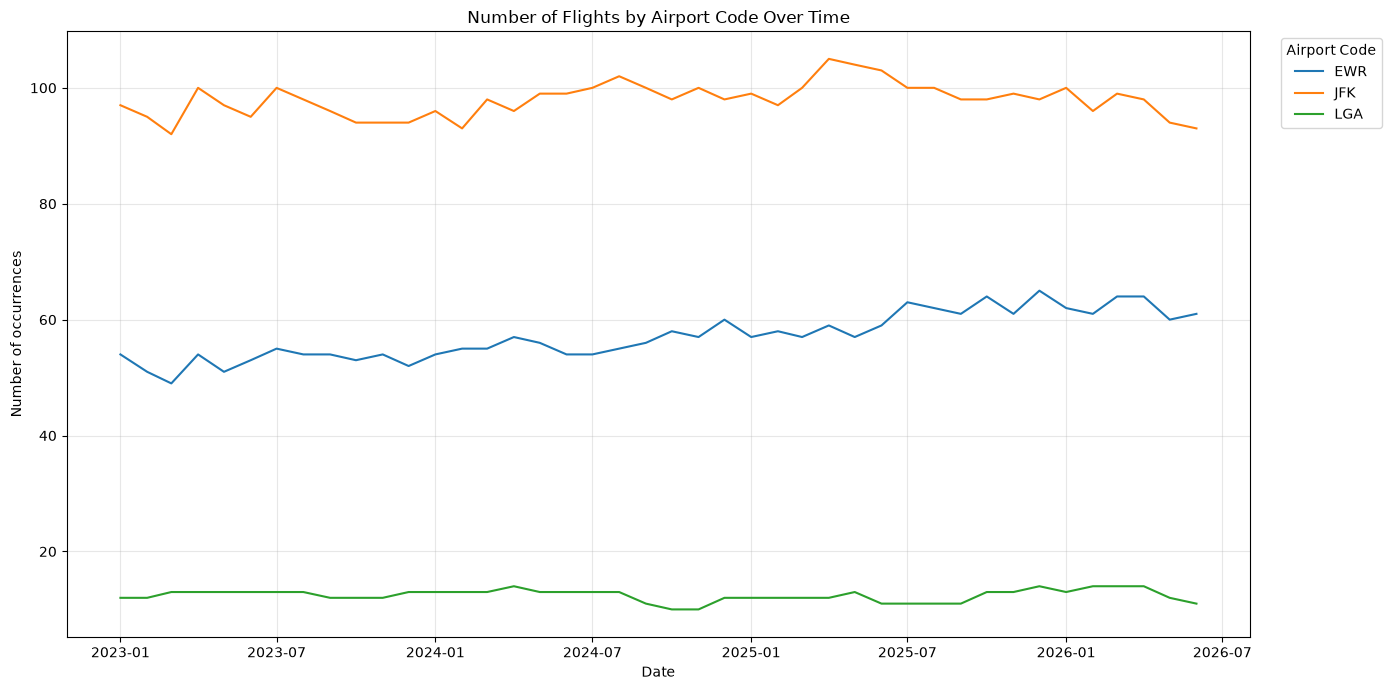

In [ ]:
# Aggregate number of occurrences by date and Airport Code
daily_counts = (
    passenger_flights
    .groupBy("date", "Airport Code")
    .count()
    .orderBy("date")
)

# Bring the relatively small aggregated result to Pandas
plot_df = daily_counts.toPandas()

# Make sure date is a proper datetime
plot_df["date"] = pd.to_datetime(plot_df["date"])

# Pivot so each Airport Code becomes a separate series
plot_data = plot_df.pivot(
    index="date",
    columns="Airport Code",
    values="count"
).fillna(0)

# Plot
plt.figure(figsize=(14, 7))

for airport in plot_data.columns:
    plt.plot(
        plot_data.index,
        plot_data[airport],
        label=airport
    )

plt.xlabel("Date")
plt.ylabel("Number of occurrences")
plt.title("Number of Flights by Airport Code Over Time")
plt.legend(title="Airport Code", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
money_stats = combined.filter(F.col('PULocationID').isin([132, 138, 1])).select('date', 'PULocationID', 'log_total_revenue')
money_stats = money_stats.groupby(F.date_trunc('month', 'date').alias('date'), 'PULocationID').agg(F.sum('log_total_revenue').alias('total_log_revenue')).orderBy('date', 'PULocationID')
print(money_stats.count())
money_stats.show(10)

126


+-------------------+------------+------------------+
|               date|PULocationID| total_log_revenue|
+-------------------+------------+------------------+
|2023-01-01 00:00:00|           1| 62.90569991428714|
|2023-01-01 00:00:00|         132|395.52150975908665|
|2023-01-01 00:00:00|         138| 373.5295874661698|
|2023-02-01 00:00:00|           1|56.303121585206135|
|2023-02-01 00:00:00|         132| 355.7021224727913|
|2023-02-01 00:00:00|         138| 338.8676835614447|
|2023-03-01 00:00:00|           1| 85.56436396500621|
|2023-03-01 00:00:00|         132| 398.8821159328657|
|2023-03-01 00:00:00|         138| 382.1823937547461|
|2023-04-01 00:00:00|           1|57.877600623253635|
+-------------------+------------+------------------+
only showing top 10 rows


In [ ]:
airport_stats = passenger_flights.filter(F.col('Airport Code').isin(['JFK', 'LGA', 'EWR'])).select('date', 'Airport Code', 'Revenue Passenger Volume')
airport_stats = airport_stats.withColumn('PULocationID', F.when(F.col('Airport Code') == 'JFK', 132).when(F.col('Airport Code') == 'LGA', 138).when(F.col('Airport Code') == 'EWR', 1)).drop('Airport Code')
airport_stats = airport_stats.groupby(F.date_trunc('month', 'date').alias('date'), 'PULocationID').agg(F.sum('Revenue Passenger Volume').alias('total_passengers')).orderBy('date', 'PULocationID')
print(airport_stats.count())
airport_stats.show(10)

126
+-------------------+------------+----------------+
|               date|PULocationID|total_passengers|
+-------------------+------------+----------------+
|2023-01-01 00:00:00|           1|         1801687|
|2023-01-01 00:00:00|         132|         2273636|
|2023-01-01 00:00:00|         138|         1096140|
|2023-02-01 00:00:00|           1|         1678787|
|2023-02-01 00:00:00|         132|         2007887|
|2023-02-01 00:00:00|         138|         1077195|
|2023-03-01 00:00:00|           1|         2090346|
|2023-03-01 00:00:00|         132|         2597725|
|2023-03-01 00:00:00|         138|         1399527|
|2023-04-01 00:00:00|           1|         2090915|
+-------------------+------------+----------------+
only showing top 10 rows


In [ ]:
airport_stats.filter(F.col('date') == '2024-07-01').show()

+-------------------+------------+----------------+
|               date|PULocationID|total_passengers|
+-------------------+------------+----------------+
|2024-07-01 00:00:00|           1|         2231243|
|2024-07-01 00:00:00|         132|         3101076|
|2024-07-01 00:00:00|         138|         1481728|
+-------------------+------------+----------------+



In [ ]:
combined_with_flights = money_stats.join(airport_stats, on=['date', 'PULocationID'], how='left')
combined_with_flights.show(5)

+-------------------+------------+------------------+----------------+
|               date|PULocationID| total_log_revenue|total_passengers|
+-------------------+------------+------------------+----------------+
|2024-08-01 00:00:00|         138| 377.9100894045744|         1463912|
|2025-10-01 00:00:00|           1|110.42523739904043|         2045211|
|2026-05-01 00:00:00|           1| 70.11817128715997|         2003058|
|2025-01-01 00:00:00|           1| 64.10766810702182|         1836820|
|2024-11-01 00:00:00|           1| 60.08230295837649|         1935061|
+-------------------+------------+------------------+----------------+
only showing top 5 rows


In [ ]:
# remove rows where total_log_revenue is less than 10
combined_with_flights = combined_with_flights.filter(F.col('total_log_revenue') >= 10)

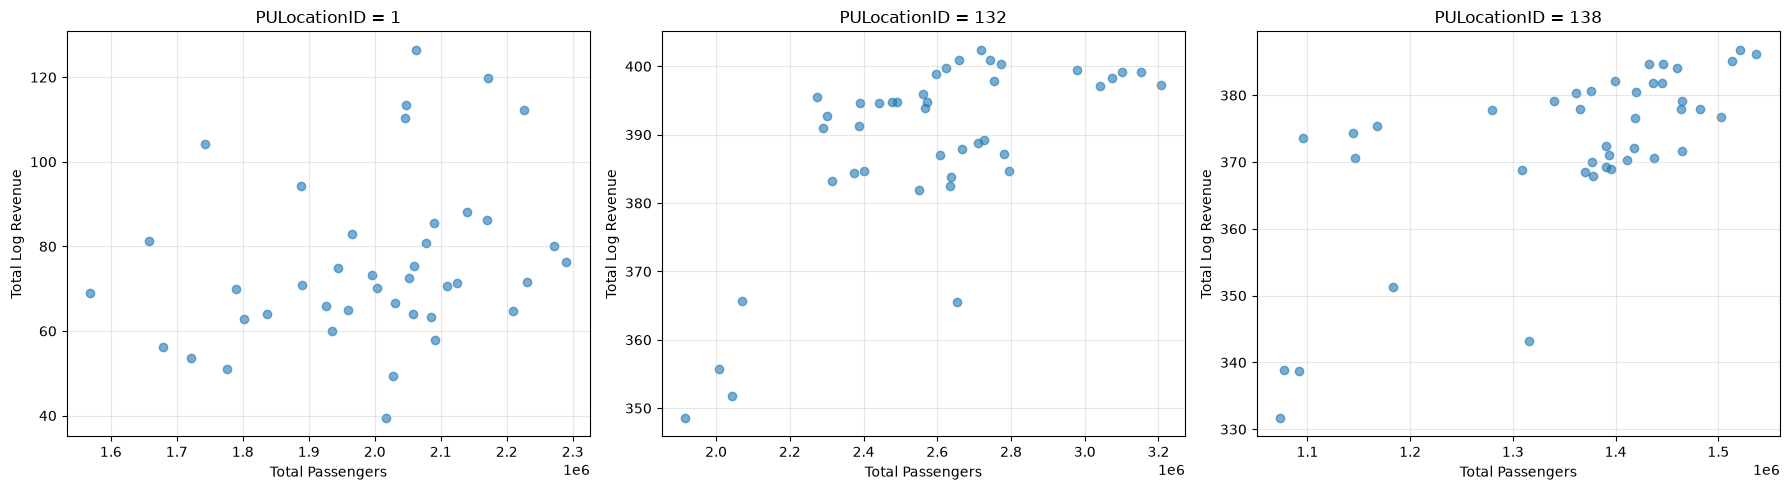

In [ ]:
# Get the three PULocationID values
locations = [
    row["PULocationID"]
    for row in combined_with_flights
        .select("PULocationID")
        .distinct()
        .orderBy("PULocationID")
        .collect()
]

# Create a 1x3 collection of subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, location in zip(axes, locations):
    # Filter to the current location and collect the plotting data
    data = (
        combined_with_flights
        .filter(combined_with_flights.PULocationID == location)
        .select("total_passengers", "total_log_revenue")
        .dropna()
        .collect()
    )

    x = [row["total_passengers"] for row in data]
    y = [row["total_log_revenue"] for row in data]

    ax.scatter(x, y, alpha=0.6)

    ax.set_title(f"PULocationID = {location}")
    ax.set_xlabel("Total Passengers")
    ax.set_ylabel("Total Log Revenue")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

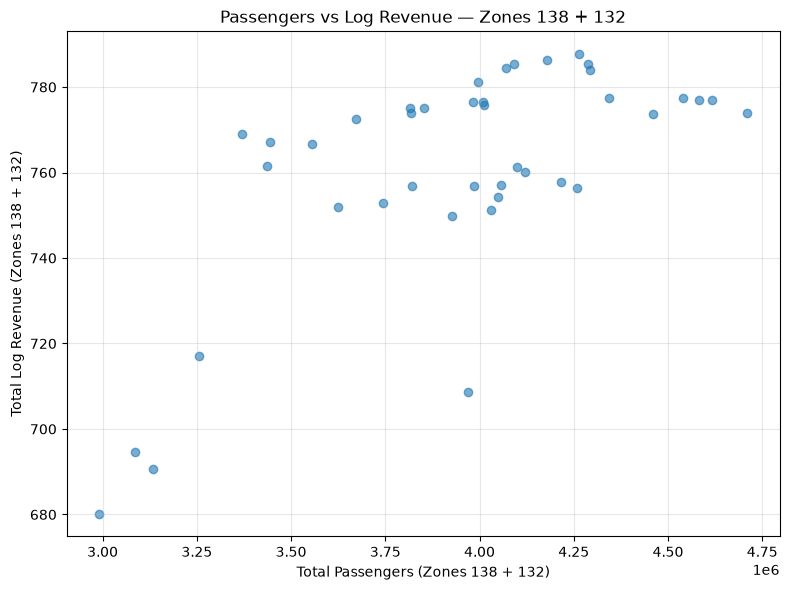

In [ ]:
# Filter to zones 138 and 132
# Then group by date and sum across the two zones
daily_sums = (
    combined_with_flights
    .filter(combined_with_flights.PULocationID.isin([138, 132]))
    .groupBy("date")
    .agg(
        {"total_passengers": "sum",
         "total_log_revenue": "sum"}
    )
    .orderBy("date")
)

# Collect for plotting
data = daily_sums.collect()

x = [row["sum(total_passengers)"] for row in data]
y = [row["sum(total_log_revenue)"] for row in data]

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6)

plt.xlabel("Total Passengers (Zones 138 + 132)")
plt.ylabel("Total Log Revenue (Zones 138 + 132)")
plt.title("Passengers vs Log Revenue — Zones 138 + 132")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()